In [16]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Load Dataset
df = pd.read_csv('/content/diabetes.csv')
# printing the first 5 rows of the dataset
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


OUTCOME DISTRIBUTION ANALYSIS
Total samples: 768

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


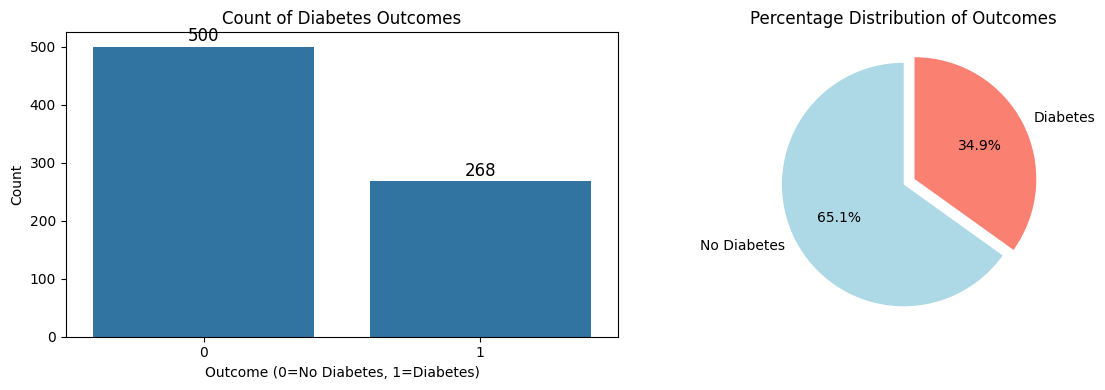

In [18]:
# 1. Total number of samples
print("OUTCOME DISTRIBUTION ANALYSIS")
print(f"Total samples: {len(df)}")

# 2. Count the values ​​in the Outcome column
outcome_counts = df['Outcome'].value_counts()
print("\nOutcome Distribution:")
print(outcome_counts)

# 3. Percentages
outcome_percentages = df['Outcome'].value_counts(normalize=True) * 100
print("\nOutcome Percentages:")
print(outcome_percentages)

# 4. Visual representation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Outcome', data=df, ax=axes[0])
axes[0].set_title('Count of Diabetes Outcomes')
axes[0].set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
axes[0].set_ylabel('Count')

# Add count numbers on bars
for i, count in enumerate(outcome_counts):
    axes[0].text(i, count + 10, str(count), ha='center', fontsize=12)

# Pie chart
axes[1].pie(outcome_counts, labels=['No Diabetes', 'Diabetes'],
           autopct='%1.1f%%', colors=['lightblue', 'salmon'],
           startangle=90, explode=[0, 0.1])
axes[1].set_title('Percentage Distribution of Outcomes')

plt.tight_layout()
plt.show()

Number of zeros after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      27.334635   94.652344   
std       3.369578   30.438286      12.096642       9.229014  105.547598   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      23.000000   30.500000   
50%       3.000000  117.000000      72.000000      23.000000   31.250000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450911                

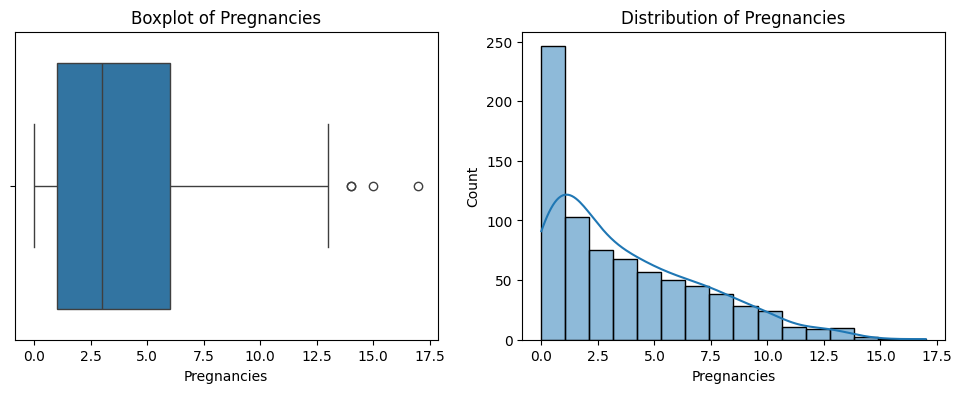

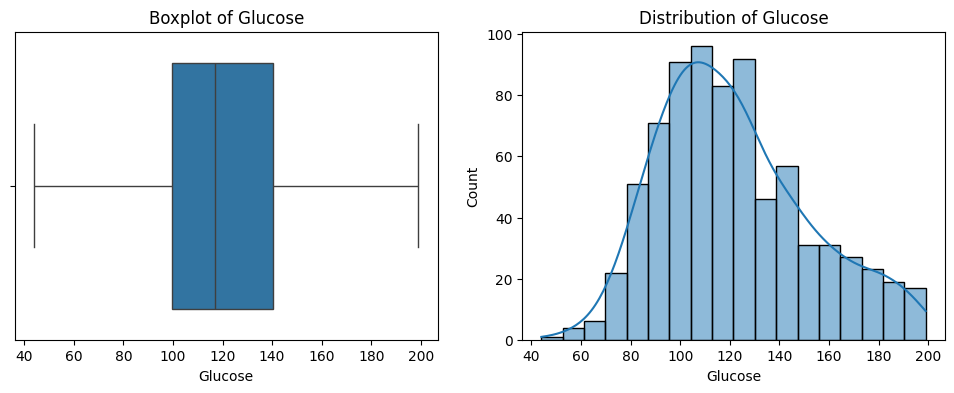

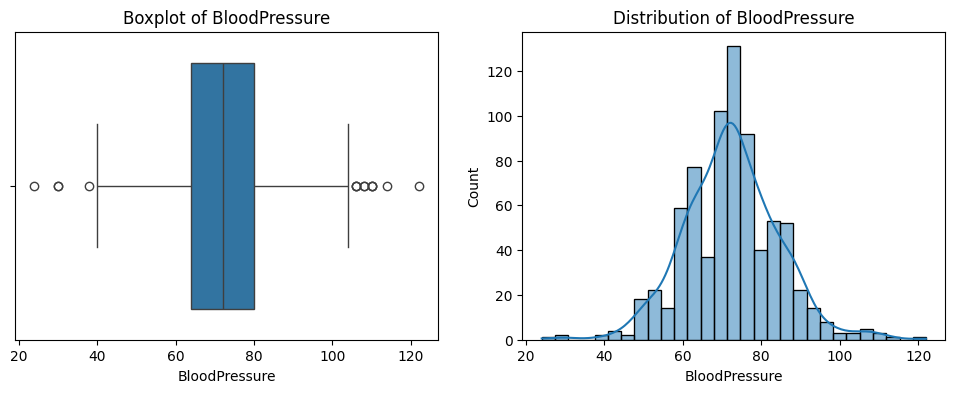

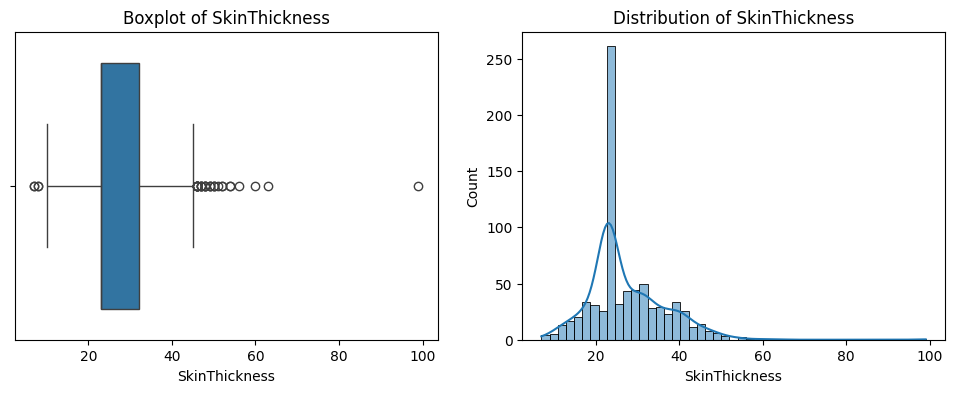

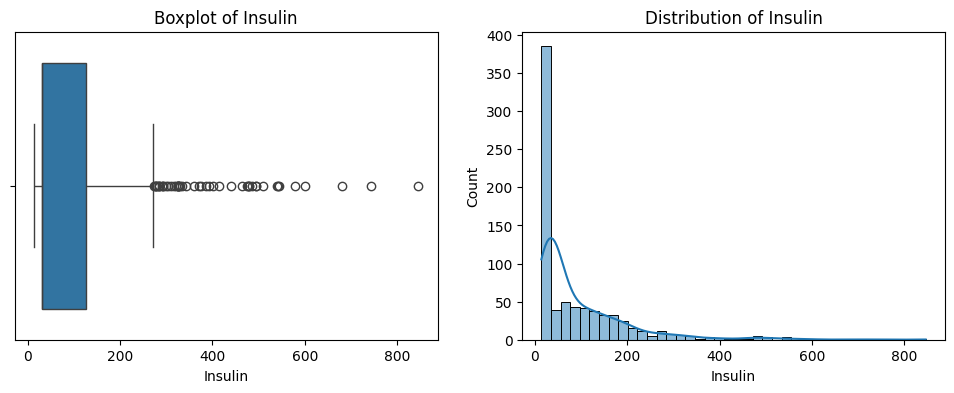

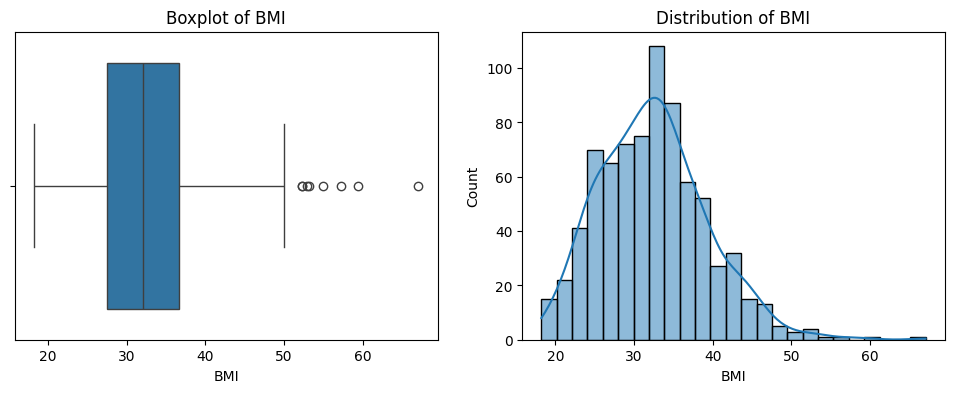

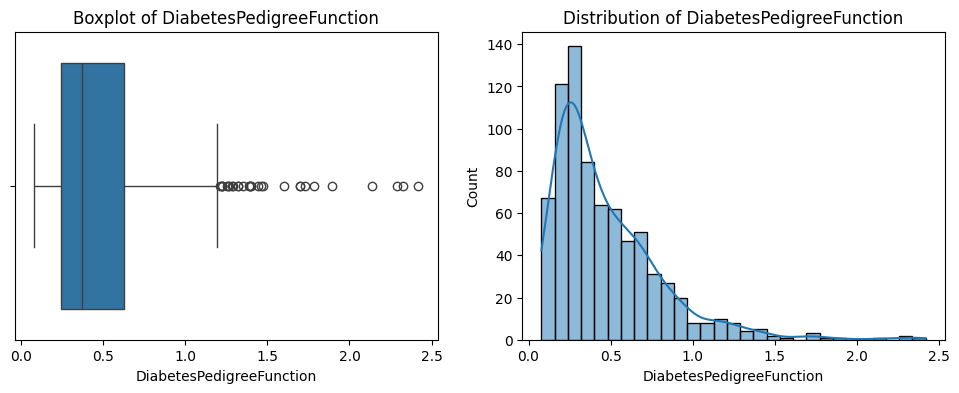

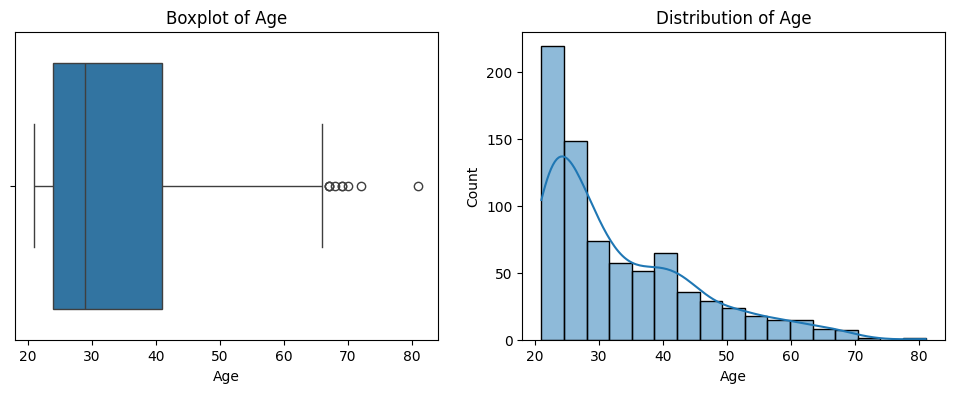

In [19]:
# Columns with zero as missing values
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with median
for col in missing_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)

# Quick check
print("Number of zeros after imputation:")
print((df[missing_cols] == 0).sum())

# Optional: Summary statistics
print(df.describe())

# Outliers detection + distribution plots
numeric_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    # Distribution plot
    plt.subplot(1,2,2)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.show()
# Detect outliers using Z-score
outlier_summary = {}
for col in numeric_cols:
    z_scores = stats.zscore(df[col])
    outliers = df[col][abs(z_scores) > 3]
    outlier_summary[col] = len(outliers)

In [20]:
print("\nNumber of outliers per column (Z-score > 3):")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")


Number of outliers per column (Z-score > 3):
Pregnancies: 4
Glucose: 0
BloodPressure: 8
SkinThickness: 4
Insulin: 19
BMI: 5
DiabetesPedigreeFunction: 11
Age: 5


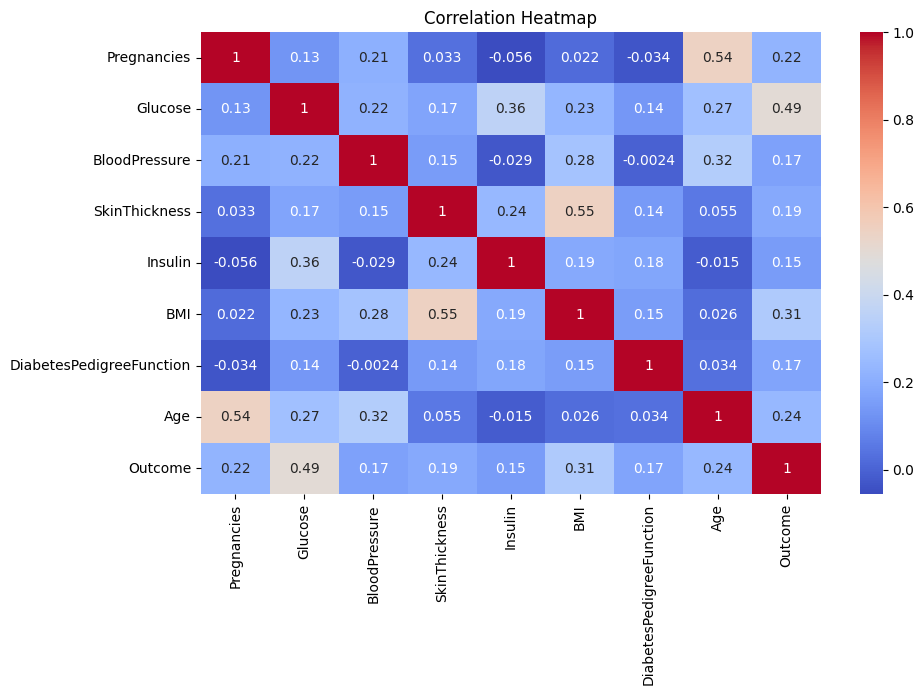

Integer features (will NOT be scaled): ['Pregnancies', 'Age']
Continuous features (will be scaled): ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']

APPLYING SMOTE BEFORE SCALING
DATA SPLITTING: 70% TRAIN, 15% VALIDATION, 15% TEST

Training set (unscaled): (536, 8) (536 samples)
Validation set (unscaled): (116, 8) (116 samples)
Test set (unscaled): (116, 8) (116 samples)

----------------------------------------
Class Distribution in Each Set (Before SMOTE):
----------------------------------------

Training Set:
  Class 0 (No Diabetes): 349 samples (65.1%)
  Class 1 (Diabetes): 187 samples (34.9%)

Validation Set:
  Class 0 (No Diabetes): 75 samples (64.7%)
  Class 1 (Diabetes): 41 samples (35.3%)

Test Set:
  Class 0 (No Diabetes): 76 samples (65.5%)
  Class 1 (Diabetes): 40 samples (34.5%)
HANDLING CLASS IMBALANCE WITH SMOTE (APPLIED TO UNSCALED DATA)

Before SMOTE (Training Set - Unscaled):
  Class 0: 349 samples (65.1%)
  Class 1: 187 sa

In [21]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df_original = df.copy()

integer_features = ['Pregnancies', 'Age']
continuous_features = ['Glucose', 'BloodPressure', 'SkinThickness',
                       'Insulin', 'BMI', 'DiabetesPedigreeFunction']

print(f"Integer features (will NOT be scaled): {integer_features}")
print(f"Continuous features (will be scaled): {continuous_features}")
print("\n" + "="*60)
print("APPLYING SMOTE BEFORE SCALING")
print("="*60)

# Keep original unscaled data for SMOTE
X_unscaled = df_original.drop('Outcome', axis=1)
y_unscaled = df_original['Outcome']

print("DATA SPLITTING: 70% TRAIN, 15% VALIDATION, 15% TEST")

# Split the UNSCALED data first
X_train_val_u, X_test_u, y_train_val_u, y_test_u = train_test_split(
    X_unscaled, y_unscaled, test_size=0.15, random_state=42, stratify=y_unscaled
)

X_train_u, X_val_u, y_train_u, y_val_u = train_test_split(
    X_train_val_u, y_train_val_u,
    test_size=(0.15/0.85),  # 0.15/0.85 = 0.1765
    random_state=42,
    stratify=y_train_val_u
)

print(f"\nTraining set (unscaled): {X_train_u.shape} ({len(y_train_u)} samples)")
print(f"Validation set (unscaled): {X_val_u.shape} ({len(y_val_u)} samples)")
print(f"Test set (unscaled): {X_test_u.shape} ({len(y_test_u)} samples)")

# Check the distribution of the output in each group (unscaled)
print("\n" + "-"*40)
print("Class Distribution in Each Set (Before SMOTE):")
print("-"*40)

print(f"\nTraining Set:")
print(f"  Class 0 (No Diabetes): {np.sum(y_train_u == 0)} samples ({np.sum(y_train_u == 0)/len(y_train_u)*100:.1f}%)")
print(f"  Class 1 (Diabetes): {np.sum(y_train_u == 1)} samples ({np.sum(y_train_u == 1)/len(y_train_u)*100:.1f}%)")

print(f"\nValidation Set:")
print(f"  Class 0 (No Diabetes): {np.sum(y_val_u == 0)} samples ({np.sum(y_val_u == 0)/len(y_val_u)*100:.1f}%)")
print(f"  Class 1 (Diabetes): {np.sum(y_val_u == 1)} samples ({np.sum(y_val_u == 1)/len(y_val_u)*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Class 0 (No Diabetes): {np.sum(y_test_u == 0)} samples ({np.sum(y_test_u == 0)/len(y_test_u)*100:.1f}%)")
print(f"  Class 1 (Diabetes): {np.sum(y_test_u == 1)} samples ({np.sum(y_test_u == 1)/len(y_test_u)*100:.1f}%)")

# HANDLING CLASS IMBALANCE WITH SMOTE (ON UNSCALED DATA)
print("HANDLING CLASS IMBALANCE WITH SMOTE (APPLIED TO UNSCALED DATA)")

from imblearn.over_sampling import SMOTE

# SMOTE application for UNSCALED training data only
smote = SMOTE(random_state=42)
X_train_balanced_u, y_train_balanced_u = smote.fit_resample(X_train_u, y_train_u)

print(f"\nBefore SMOTE (Training Set - Unscaled):")
print(f"  Class 0: {np.sum(y_train_u == 0)} samples ({np.sum(y_train_u == 0)/len(y_train_u)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_train_u == 1)} samples ({np.sum(y_train_u == 1)/len(y_train_u)*100:.1f}%)")

print(f"\nAfter SMOTE (Training Set - Unscaled):")
print(f"  Class 0: {np.sum(y_train_balanced_u == 0)} samples ({np.sum(y_train_balanced_u == 0)/len(y_train_balanced_u)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_train_balanced_u == 1)} samples ({np.sum(y_train_balanced_u == 1)/len(y_train_balanced_u)*100:.1f}%)")

print(f"\nTotal increase in training samples: {len(X_train_balanced_u) - len(X_train_u)} samples")

In [22]:
# ===================== NOW SCALE THE DATA =====================
print("\n" + "="*60)
print("SCALING DATA AFTER SMOTE")
print("="*60)

# DEBUG: First check what columns we have in X_train_balanced_u
print("\nDEBUG: Checking column structure before scaling")
print(f"Type of X_train_balanced_u: {type(X_train_balanced_u)}")
if hasattr(X_train_balanced_u, 'columns'):
    print(f"Columns in X_train_balanced_u: {X_train_balanced_u.columns.tolist()}")
    print(f"First row - Pregnancies value: {X_train_balanced_u.iloc[0]['Pregnancies'] if 'Pregnancies' in X_train_balanced_u.columns else 'Column not found'}")
else:
    print("X_train_balanced_u is an array, not DataFrame")
    print(f"Shape: {X_train_balanced_u.shape}")

# Define the CORRECT feature order for the dataset
correct_feature_order = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# If X_train_balanced_u is a DataFrame, reorder columns
if hasattr(X_train_balanced_u, 'columns'):
    # Reorder to correct order
    X_train_balanced_u = X_train_balanced_u[correct_feature_order]
    X_val_u = X_val_u[correct_feature_order]
    X_test_u = X_test_u[correct_feature_order]
else:
    # If it's an array, we need to check if we have the right mapping
    print("\nWARNING: X_train_balanced_u is an array, not DataFrame")
    print("Assuming correct feature order based on original df_original")

    # Convert arrays back to DataFrames with correct column names
    X_train_balanced_u = pd.DataFrame(X_train_balanced_u, columns=correct_feature_order)
    X_val_u = pd.DataFrame(X_val_u, columns=correct_feature_order)
    X_test_u = pd.DataFrame(X_test_u, columns=correct_feature_order)

print("\n✓ Verified feature order:")
print(f"Columns: {X_train_balanced_u.columns.tolist()}")
print(f"First row - Pregnancies: {X_train_balanced_u.iloc[0]['Pregnancies']} (should be 0-20)")

# Scale only the continuous features (not integer features)
scaler = StandardScaler()

# For the balanced training data
# Make sure we're using DataFrame indexing to get correct columns
X_train_balanced_cont = X_train_balanced_u[continuous_features].values
X_train_balanced_cont_scaled = scaler.fit_transform(X_train_balanced_cont)

# For validation data (use the same scaler!)
X_val_cont = X_val_u[continuous_features].values
X_val_cont_scaled = scaler.transform(X_val_cont)

# For test data (use the same scaler!)
X_test_cont = X_test_u[continuous_features].values
X_test_cont_scaled = scaler.transform(X_test_cont)

# Combine with integer features
X_train_integer = X_train_balanced_u[integer_features].values
X_val_integer = X_val_u[integer_features].values
X_test_integer = X_test_u[integer_features].values

X_train_balanced = np.hstack([X_train_integer, X_train_balanced_cont_scaled])
X_val = np.hstack([X_val_integer, X_val_cont_scaled])
X_test = np.hstack([X_test_integer, X_test_cont_scaled])

feature_names = integer_features + continuous_features

print("\nFirst 5 rows after SMOTE and selective scaling:")
sample_df = pd.DataFrame(X_train_balanced[:5], columns=feature_names)
print(sample_df.to_string(index=False))
print("\nNote: Pregnancies and Age are original integer values (not scaled)")

print(f"\nFinal dataset sizes:")
print(f"Training set (balanced & scaled): {X_train_balanced.shape} ({len(y_train_balanced_u)} samples)")
print(f"Validation set (scaled): {X_val.shape} ({len(y_val_u)} samples)")
print(f"Test set (scaled): {X_test.shape} ({len(y_test_u)} samples)")

# Export SMOTE data as csv (UNSCALED VERSION - more meaningful)
print("\n" + "="*60)
print("EXPORTING SMOTE-BALANCED DATA (UNSCALED) AS CSV FILE")
print("="*60)

# 1. Get the original feature names IN CORRECT ORDER
feature_names_unscaled = correct_feature_order

# 2. Create DataFrame from balanced UNSCALED data WITH VERIFIED ORDER
X_train_balanced_unscaled_df = X_train_balanced_u.copy()  # Already has correct order
X_train_balanced_unscaled_df = pd.DataFrame(X_train_balanced_u, columns=feature_names_unscaled)

# 3. Add the Outcome column
X_train_balanced_unscaled_df['Outcome'] = y_train_balanced_u

# 4. Add a column to identify synthetic vs original samples
X_train_balanced_unscaled_df['Sample_Type'] = 'Original'

# Identify which samples are synthetic (the ones added by SMOTE)
# The first len(y_train_u) samples are original, the rest are synthetic
training_original = len(y_train_u)
X_train_balanced_unscaled_df.iloc[training_original:, X_train_balanced_unscaled_df.columns.get_loc('Sample_Type')] = 'Synthetic'

# 5. VERIFY DATA BEFORE SAVING
print("\n✓ Data verification before export:")
print(f"Pregnancies range: {X_train_balanced_unscaled_df['Pregnancies'].min():.0f} to {X_train_balanced_unscaled_df['Pregnancies'].max():.0f}")
print(f"Glucose range: {X_train_balanced_unscaled_df['Glucose'].min():.0f} to {X_train_balanced_unscaled_df['Glucose'].max():.0f}")
print(f"Age range: {X_train_balanced_unscaled_df['Age'].min():.0f} to {X_train_balanced_unscaled_df['Age'].max():.0f}")

# Check if values are realistic
is_realistic = True
if X_train_balanced_unscaled_df['Pregnancies'].max() > 20:
    print(f"\n WARNING: Unrealistic Pregnancies value: {X_train_balanced_unscaled_df['Pregnancies'].max():.0f}")
    is_realistic = False
if X_train_balanced_unscaled_df['Glucose'].max() > 300:
    print(f" WARNING: Unrealistic Glucose value: {X_train_balanced_unscaled_df['Glucose'].max():.0f}")
    is_realistic = False
if X_train_balanced_unscaled_df['Age'].max() > 120:
    print(f" WARNING: Unrealistic Age value: {X_train_balanced_unscaled_df['Age'].max():.0f}")
    is_realistic = False

if is_realistic:
    # Save to CSV file
    csv_filename_unscaled = 'SMOTE_Balanced_Unscaled_Training_Data.csv'
    X_train_balanced_unscaled_df.to_csv(csv_filename_unscaled, index=False)

    print(f"\n✓ SMOTE-balanced UNSCALED data exported successfully!")
    print(f"✓ File name: {csv_filename_unscaled}")
    print(f"✓ Total samples: {len(X_train_balanced_unscaled_df)}")
    print(f"   - Original samples: {training_original}")
    print(f"   - Synthetic samples: {len(X_train_balanced_unscaled_df) - training_original}")
    print(f"   - Class 0 (No Diabetes): {np.sum(y_train_balanced_u == 0)} samples")
    print(f"   - Class 1 (Diabetes): {np.sum(y_train_balanced_u == 1)} samples")
else:
    print("\n✗ ERROR: Unrealistic values detected! Not exporting data.")
    print("Check the SMOTE process and column ordering.")

# Check for negative values in the unscaled data
print(f"\n Checking for negative values:")
for feature in feature_names_unscaled:
    min_val = X_train_balanced_unscaled_df[feature].min()
    if min_val < 0:
        print(f"  Warning: {feature} has negative values (min: {min_val:.2f})")
    else:
        print(f"  {feature}: All values >= {min_val:.2f}")

print("\nFirst 5 rows of exported UNSCALED data (with realistic values):")
print(X_train_balanced_unscaled_df.head().to_string(index=False))

# Also export the scaled version for modeling
X_train_balanced_scaled_df = pd.DataFrame(X_train_balanced, columns=feature_names)
X_train_balanced_scaled_df['Outcome'] = y_train_balanced_u
csv_filename_scaled = 'SMOTE_Balanced_Scaled_Training_Data.csv'
X_train_balanced_scaled_df.to_csv(csv_filename_scaled, index=False)
print(f"\n Scaled version for modeling saved as: {csv_filename_scaled}")

# Update variables for consistency with rest of code
X_train = X_train_balanced
y_train = y_train_balanced_u
y_val = y_val_u  # Explicitly assign y_val
y_test = y_test_u # Explicitly assign y_test

print(f"\n DATA PREPARATION COMPLETE!")
print(f"  X_train, y_train: Balanced & scaled training data")
print(f"  X_val, y_val: Scaled validation data")
print(f"  X_test, y_test: Scaled test data")


SCALING DATA AFTER SMOTE

DEBUG: Checking column structure before scaling
Type of X_train_balanced_u: <class 'pandas.core.frame.DataFrame'>
Columns in X_train_balanced_u: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
First row - Pregnancies value: 0.0

✓ Verified feature order:
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
First row - Pregnancies: 0.0 (should be 0-20)

First 5 rows after SMOTE and selective scaling:
 Pregnancies  Age   Glucose  BloodPressure  SkinThickness   Insulin       BMI  DiabetesPedigreeFunction
         0.0 26.0  0.109237       3.179866       1.976697  0.347585  5.131873                 -0.537785
         1.0 23.0  0.570942       1.145995       0.261942  2.383979 -0.416841                  1.302064
         2.0 27.0 -1.341836      -0.633642      -0.488263 -0.665522  1.007828                  1.424079
         2.0 22.0 

In [23]:
from google.colab import files
files.download(csv_filename_unscaled)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# TRAINING MULTIPLE MODELS
print("TRAINING AND EVALUATING MULTIPLE MODELS")

# Import the necessary machine learning models and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Define the models to train
# Each model is stored in a dictionary with a name for easy reference
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),  # Linear model for classification
    "Random Forest": RandomForestClassifier(random_state=42),                    # Ensemble of decision trees
    "Support Vector Machine": SVC(probability=True, random_state=42),           # SVM classifier with probability output enabled
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)  # Gradient boosting tree model
}

# Dictionary to store the results of each model
results = {}

# Loop through each model in the dictionary
for name, model in models.items():
    print(f"Training: {name}")  # Print the model currently being trained

    # Train the model on the balanced training data
    model.fit(X_train_balanced, y_train)

    # Make predictions on the validation set
    y_val_pred = model.predict(X_val)

    # Get predicted probabilities for AUC calculation if supported
    y_val_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate performance metrics
    accuracy = accuracy_score(y_val, y_val_pred)       # Overall correctness of the model
    precision = precision_score(y_val, y_val_pred)    # How many predicted positives are true positives
    recall = recall_score(y_val, y_val_pred)          # How many actual positives are correctly predicted
    f1 = f1_score(y_val, y_val_pred)                  # Harmonic mean of precision and recall
    auc = roc_auc_score(y_val, y_val_pred_proba) if y_val_pred_proba is not None else None  # Area under ROC curve

    # Save metrics and the trained model in results dictionary
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "Model": model
    }

    # Print the metrics for the current model
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}" if auc else "AUC-ROC:   Not available")

    # Display the confusion matrix #sfv file llsmote w w file after balancing table comparison ll5 models m3 ellit review
    print("\nConfusion Matrix:")# kfold m3 eltraining msh b3dha msh elhandout ana 3amla elhandout bs
    print(confusion_matrix(y_val, y_val_pred))

    # Print a detailed classification report (precision, recall, f1-score per class)
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))

TRAINING AND EVALUATING MULTIPLE MODELS
Training: Logistic Regression
Accuracy:  0.7500
Precision: 0.6304
Recall:    0.7073
F1-Score:  0.6667
AUC-ROC:   0.8380

Confusion Matrix:
[[58 17]
 [12 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        75
           1       0.63      0.71      0.67        41

    accuracy                           0.75       116
   macro avg       0.73      0.74      0.73       116
weighted avg       0.76      0.75      0.75       116

Training: Random Forest
Accuracy:  0.7586
Precision: 0.6275
Recall:    0.7805
F1-Score:  0.6957
AUC-ROC:   0.8407

Confusion Matrix:
[[56 19]
 [ 9 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        75
           1       0.63      0.78      0.70        41

    accuracy                           0.76       116
   macro avg       0.74      0.76      0.75       116
wei

In [25]:
# COMPARISON OF MODELS
print("MODEL COMPARISON SUMMARY")

import pandas as pd

# Converting the results dictionary to a DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
results_df = results_df.round(4)
results_df = results_df.sort_values(by='AUC-ROC', ascending=False)

print(results_df)

MODEL COMPARISON SUMMARY
                        Accuracy  Precision  Recall  F1-Score  AUC-ROC
Random Forest             0.7586     0.6275  0.7805    0.6957   0.8407
Logistic Regression       0.7500     0.6304  0.7073    0.6667   0.8380
XGBoost                   0.7500     0.6250  0.7317    0.6742   0.8078
Support Vector Machine    0.6983     0.5536  0.7561    0.6392   0.7720


In [26]:
# BEFORE vs AFTER BALANCING COMPARISON
print("BEFORE vs AFTER BALANCING COMPARISON FOR ALL MODELS")

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

before_after_results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print('='*60)

    # BEFORE BALANCING
    print("\n1. BEFORE SMOTE (Original Imbalanced Data):")
    print("-"*40)

    model_before = model
    # Use X_train_u and y_train_u for before SMOTE
    model_before.fit(X_train_u, y_train_u)
    y_val_pred_before = model_before.predict(X_val)

    acc_before = accuracy_score(y_val, y_val_pred_before)
    prec_before = precision_score(y_val, y_val_pred_before)
    rec_before = recall_score(y_val, y_val_pred_before)
    f1_before = f1_score(y_val, y_val_pred_before)

    print(f"Accuracy:  {acc_before:.4f}")
    print(f"Precision: {prec_before:.4f}")
    print(f"Recall:    {rec_before:.4f}")
    print(f"F1-Score:  {f1_before:.4f}")

    # AFTER BALANCING
    print("\n2. AFTER SMOTE (Balanced Data):")
    print("-"*40)

    model_after = model
    # Use X_train and y_train for after SMOTE (these are already balanced and scaled)
    model_after.fit(X_train, y_train)
    y_val_pred_after = model_after.predict(X_val)

    acc_after = accuracy_score(y_val, y_val_pred_after)
    prec_after = precision_score(y_val, y_val_pred_after)
    rec_after = recall_score(y_val, y_val_pred_after)
    f1_after = f1_score(y_val, y_val_pred_after)

    print(f"Accuracy:  {acc_after:.4f}")
    print(f"Precision: {prec_after:.4f}")
    print(f"Recall:    {rec_after:.4f}")
    print(f"F1-Score:  {f1_after:.4f}")

    # IMPROVEMENT
    print("\n3. IMPROVEMENT:")
    print("-"*40)

    improvement_acc = acc_after - acc_before
    improvement_rec = rec_after - rec_before
    improvement_f1 = f1_after - f1_before

    print(f"Accuracy Improvement:  {improvement_acc:+.4f}")
    print(f"Recall Improvement:    {improvement_rec:+.4f}")
    print(f"F1-Score Improvement:  {improvement_f1:+.4f}")

    before_after_results[model_name] = {
        'Before': {'Accuracy': acc_before, 'Precision': prec_before, 'Recall': rec_before, 'F1-Score': f1_before},
        'After': {'Accuracy': acc_after, 'Precision': prec_after, 'Recall': rec_after, 'F1-Score': f1_after}
    }

# COMPREHENSIVE COMPARISON TABLE
print("COMPREHENSIVE BEFORE-AFTER BALANCING COMPARISON TABLE")

import pandas as pd

comparison_rows = []
for model_name in models.keys():
    before = before_after_results[model_name]['Before']
    after = before_after_results[model_name]['After']

    comparison_rows.append({
        'Model': model_name,
        'Metric': 'Accuracy',
        'Before SMOTE': before['Accuracy'],
        'After SMOTE': after['Accuracy'],
        'Difference': after['Accuracy'] - before['Accuracy']
    })

    comparison_rows.append({
        'Model': model_name,
        'Metric': 'Recall',
        'Before SMOTE': before['Recall'],
        'After SMOTE': after['Recall'],
        'Difference': after['Recall'] - before['Recall']
    })

    comparison_rows.append({
        'Model': model_name,
        'Metric': 'F1-Score',
        'Before SMOTE': before['F1-Score'],
        'After SMOTE': after['F1-Score'],
        'Difference': after['F1-Score'] - before['F1-Score']
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['Before SMOTE'] = comparison_df['Before SMOTE'].round(4)
comparison_df['After SMOTE'] = comparison_df['After SMOTE'].round(4)
comparison_df['Difference'] = comparison_df['Difference'].round(4)

print("\nDetailed Comparison Table:")
print("-"*80)

for model_name in models.keys():
    model_df = comparison_df[comparison_df['Model'] == model_name]
    print(f"\n{model_name}:")
    print(model_df[['Metric', 'Before SMOTE', 'After SMOTE', 'Difference']].to_string(index=False))

# SUMMARY TABLE
print("SUMMARY: KEY IMPROVEMENTS AFTER SMOTE")

summary_rows = []
for model_name in models.keys():
    before = before_after_results[model_name]['Before']
    after = before_after_results[model_name]['After']

    summary_rows.append({
        'Model': model_name,
        'Accuracy Before': before['Accuracy'],
        'Accuracy After': after['Accuracy'],
        'Accuracy Δ': after['Accuracy'] - before['Accuracy'],
        'Recall Before': before['Recall'],
        'Recall After': after['Recall'],
        'Recall Δ': after['Recall'] - before['Recall'],
        'F1 Before': before['F1-Score'],
        'F1 After': after['F1-Score'],
        'F1 Δ': after['F1-Score'] - before['F1-Score']
    })

summary_df = pd.DataFrame(summary_rows)

for col in summary_df.columns:
    if col != 'Model':
        summary_df[col] = summary_df[col].round(4)

print("\nSummary Table:")
print(summary_df.to_string(index=False))

# FINAL ANALYSIS
print("FINAL ANALYSIS")

best_recall_improvement = -1
best_model_recall = ""
for model_name in models.keys():
    improvement = before_after_results[model_name]['After']['Recall'] - before_after_results[model_name]['Before']['Recall']
    if improvement > best_recall_improvement:
        best_recall_improvement = improvement
        best_model_recall = model_name

print(f"\nBEST RECALL IMPROVEMENT:")
print(f"  Model: {best_model_recall}")
print(f"  Recall Improvement: {best_recall_improvement:.4f} ({best_recall_improvement*100:.1f}%)")

best_model_overall = max(models.keys(), key=lambda x: before_after_results[x]['After']['F1-Score'])

print(f"\nBEST OVERALL MODEL AFTER SMOTE (based on F1-Score):")
print(f"  Model: {best_model_overall}")
print(f"  F1-Score: {before_after_results[best_model_overall]['After']['F1-Score']:.4f}")
print(f"  Recall: {before_after_results[best_model_overall]['After']['Recall']:.4f}")
print(f"  Accuracy: {before_after_results[best_model_overall]['After']['Accuracy']:.4f}")

BEFORE vs AFTER BALANCING COMPARISON FOR ALL MODELS

MODEL: Logistic Regression

1. BEFORE SMOTE (Original Imbalanced Data):
----------------------------------------
Accuracy:  0.6466
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

2. AFTER SMOTE (Balanced Data):
----------------------------------------
Accuracy:  0.7500
Precision: 0.6304
Recall:    0.7073
F1-Score:  0.6667

3. IMPROVEMENT:
----------------------------------------
Accuracy Improvement:  +0.1034
Recall Improvement:    +0.7073
F1-Score Improvement:  +0.6667

MODEL: Support Vector Machine

1. BEFORE SMOTE (Original Imbalanced Data):
----------------------------------------
Accuracy:  0.6466
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

2. AFTER SMOTE (Balanced Data):
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy:  0.6983
Precision: 0.5536
Recall:    0.7561
F1-Score:  0.6392

3. IMPROVEMENT:
----------------------------------------
Accuracy Improvement:  +0.0517
Recall Improvement:    +0.7561
F1-Score Improvement:  +0.6392

MODEL: Random Forest

1. BEFORE SMOTE (Original Imbalanced Data):
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy:  0.6466
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

2. AFTER SMOTE (Balanced Data):
----------------------------------------
Accuracy:  0.7586
Precision: 0.6275
Recall:    0.7805
F1-Score:  0.6957

3. IMPROVEMENT:
----------------------------------------
Accuracy Improvement:  +0.1121
Recall Improvement:    +0.7805
F1-Score Improvement:  +0.6957

MODEL: XGBoost

1. BEFORE SMOTE (Original Imbalanced Data):
----------------------------------------
Accuracy:  0.6466
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

2. AFTER SMOTE (Balanced Data):
----------------------------------------
Accuracy:  0.7500
Precision: 0.6250
Recall:    0.7317
F1-Score:  0.6742

3. IMPROVEMENT:
----------------------------------------
Accuracy Improvement:  +0.1034
Recall Improvement:    +0.7317
F1-Score Improvement:  +0.6742
COMPREHENSIVE BEFORE-AFTER BALANCING COMPARISON TABLE

Detailed Comparison Table:
------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
# CLASS DISTRIBUTION TABLE
print("CLASS DISTRIBUTION BEFORE AND AFTER SMOTE")

class_0_before = np.sum(y_train == 0)
class_1_before = np.sum(y_train == 1)
total_before = len(y_train)
percent_0_before = (class_0_before / total_before) * 100
percent_1_before = (class_1_before / total_before) * 100

class_0_after = np.sum(y_train_balanced_u == 0) # Use y_train_balanced_u for actual balanced counts
class_1_after = np.sum(y_train_balanced_u == 1) # Use y_train_balanced_u for actual balanced counts
total_after = len(y_train_balanced_u) # Use y_train_balanced_u for actual balanced counts
percent_0_after = (class_0_after / total_after) * 100
percent_1_after = (class_1_after / total_after) * 100

print(" Table 1: Class Distribution Before and After SMOTE")
print("-"*90)
print(f"{'Dataset Version':<25} {'Class 0 (Non-Diabetic)':<30} {'Class 1 (Diabetic)':<25} {'Total Samples':<15}")
print("-"*90)

print(f"{'Before SMOTE (Training)':<25} "
      f"{class_0_before:>3} ({percent_0_before:.1f}%){' ':15} "
      f"{class_1_before:>3} ({percent_1_before:.1f}%){' ':10} "
      f"{total_before:>15}")

print(f"{'After SMOTE (Training)':<25} "
      f"{class_0_after:>3} ({percent_0_after:.1f}%){' ':15} "
      f"{class_1_after:>3} ({percent_1_after:.1f}%){' ':10} "
      f"{total_after:>15}")

print(f"{'Validation Set':<25} "
      f"{np.sum(y_val == 0):>3} ({np.sum(y_val == 0)/len(y_val)*100:.1f}%){' ':15} "
      f"{np.sum(y_val == 1):>3} ({np.sum(y_val == 1)/len(y_val)*100:.1f}%){' ':10} "
      f"{len(y_val):>15}")

print(f"{'Test Set':<25} "
      f"{np.sum(y_test == 0):>3} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%){' ':15} "
      f"{np.sum(y_test == 1):>3} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%){' ':10} "
      f"{len(y_test):>15}")

increase_in_samples = total_after - total_before

CLASS DISTRIBUTION BEFORE AND AFTER SMOTE
 Table 1: Class Distribution Before and After SMOTE
------------------------------------------------------------------------------------------
Dataset Version           Class 0 (Non-Diabetic)         Class 1 (Diabetic)        Total Samples  
------------------------------------------------------------------------------------------
Before SMOTE (Training)   349 (50.0%)                349 (50.0%)                       698
After SMOTE (Training)    349 (50.0%)                349 (50.0%)                       698
Validation Set             75 (64.7%)                 41 (35.3%)                       116
Test Set                   76 (65.5%)                 40 (34.5%)                       116


In [29]:
# FIXED CROSS-VALIDATION ANALYSIS
print("\n" + "="*80)
print("FIXED CROSS-VALIDATION ANALYSIS")
print("="*80)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score
import numpy as np
import pandas as pd

# Get best model based on F1-Score from your previous results
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
best_model = results[best_model_name]["Model"]

print(f"Selected best model: {best_model_name}")
print(f"Selected based on: Highest F1-Score ({results[best_model_name]['F1-Score']:.4f})")

def roc_auc_scorer(estimator, X, y):
    """Custom ROC AUC scorer that handles edge cases"""
    try:
        y_pred_proba = estimator.predict_proba(X)[:, 1]
        # Check if we have both classes in y
        if len(np.unique(y)) < 2:
            return 0.5
        return roc_auc_score(y, y_pred_proba)
    except:
        return 0.5

def accuracy_scorer(estimator, X, y):
    """Custom accuracy scorer"""
    y_pred = estimator.predict(X)
    return accuracy_score(y, y_pred)

def recall_scorer(estimator, X, y):
    """Custom recall scorer"""
    y_pred = estimator.predict(X)
    try:
        return recall_score(y, y_pred)
    except:
        return 0.0

def precision_scorer(estimator, X, y):
    """Custom precision scorer"""
    y_pred = estimator.predict(X)
    try:
        return precision_score(y, y_pred)
    except:
        return 0.0

def f1_scorer(estimator, X, y):
    """Custom F1 scorer"""
    y_pred = estimator.predict(X)
    try:
        return f1_score(y, y_pred)
    except:
        return 0.0

# Use StratifiedKFold to maintain class distribution
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "-"*50)
print("K-FOLD ON ORIGINAL IMBALANCED DATA")
print("-"*50)

# Convert X_train_u to numpy array if it's a DataFrame
X_train_u_array = X_train_u.values if hasattr(X_train_u, 'values') else X_train_u
y_train_u_array = y_train_u.values if hasattr(y_train_u, 'values') else y_train_u

# Perform cross-validation on original data
cv_scores_original = []
for fold, (train_idx, val_idx) in enumerate(skfold.split(X_train_u_array, y_train_u_array)):
    X_tr, X_val = X_train_u_array[train_idx], X_train_u_array[val_idx]
    y_tr, y_val = y_train_u_array[train_idx], y_train_u_array[val_idx]

    # Train a fresh copy of the model
    model_copy = type(best_model)(**best_model.get_params())
    model_copy.fit(X_tr, y_tr)

    # Get predictions and probabilities
    y_pred_proba = model_copy.predict_proba(X_val)[:, 1]

    # Calculate AUC
    auc = roc_auc_score(y_val, y_pred_proba)
    cv_scores_original.append(auc)

    print(f"  Fold {fold+1}: AUC={auc:.4f}")

print(f"\n  Original Data AUC Scores (5-fold):")
print(f"    Individual: {np.array(cv_scores_original).round(4)}")
print(f"    Mean: {np.mean(cv_scores_original):.4f}")
print(f"    Std:  {np.std(cv_scores_original):.4f}")

print("\n" + "-"*50)
print("K-FOLD ON BALANCED DATA (AFTER SMOTE)")
print("-"*50)

# Perform cross-validation on balanced data
cv_scores_balanced = []
for fold, (train_idx, val_idx) in enumerate(skfold.split(X_train_balanced, y_train)):
    X_tr, X_val = X_train_balanced[train_idx], X_train_balanced[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train a fresh copy of the model
    model_copy = type(best_model)(**best_model.get_params())
    model_copy.fit(X_tr, y_tr)

    # Get predictions and probabilities
    y_pred_proba = model_copy.predict_proba(X_val)[:, 1]

    # Calculate AUC
    auc = roc_auc_score(y_val, y_pred_proba)
    cv_scores_balanced.append(auc)

    print(f"  Fold {fold+1}: AUC={auc:.4f}")

print(f"\n  Balanced Data AUC Scores (5-fold):")
print(f"    Individual: {np.array(cv_scores_balanced).round(4)}")
print(f"    Mean: {np.mean(cv_scores_balanced):.4f}")
print(f"    Std:  {np.std(cv_scores_balanced):.4f}")

print("\n" + "-"*50)
print("COMPARISON: ORIGINAL vs BALANCED DATA")
print("-"*50)

improvement_mean = np.mean(cv_scores_balanced) - np.mean(cv_scores_original)
improvement_std = np.std(cv_scores_balanced) - np.std(cv_scores_original)

print(f"Mean AUC Improvement: {improvement_mean:+.4f}")
print(f"Std Dev Change:       {improvement_std:+.4f}")

if improvement_mean > 0:
    print(f"\n SMOTE improved model performance!")
else:
    print(f"\n SMOTE did not improve model performance")

print("\n" + "-"*50)
print("CROSS-VALIDATION WITH MULTIPLE METRICS")
print("-"*50)

# Define scorers dictionary
scorers = {
    'accuracy': accuracy_scorer,
    'roc_auc': roc_auc_scorer,
    'recall': recall_scorer,
    'precision': precision_scorer,
    'f1': f1_scorer
}

# Perform cross-validation with multiple metrics
cv_results_summary = {}

for scorer_name, scorer_func in scorers.items():
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skfold.split(X_train_balanced, y_train)):
        X_tr, X_val = X_train_balanced[train_idx], X_train_balanced[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # Train model
        model_copy = type(best_model)(**best_model.get_params())
        model_copy.fit(X_tr, y_tr)

        # Calculate score
        score = scorer_func(model_copy, X_val, y_val)
        fold_scores.append(score)

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)

    cv_results_summary[scorer_name] = {
        'mean': mean_score,
        'std': std_score,
        'scores': fold_scores
    }

    print(f"{scorer_name.upper():<12} - Mean: {mean_score:.4f}, Std: {std_score:.4f}")

print("FINAL MODEL TRAINING AND EVALUATION")
print("-"*50)

# Train final model on combined training + validation
best_model_final = type(best_model)(**best_model.get_params())

X_final_train = np.vstack((X_train_balanced, X_val))
y_final_train = np.concatenate((y_train, y_val))

print(f"Final training data size: {X_final_train.shape[0]} samples")
print(f"  - From balanced training: {X_train_balanced.shape[0]} samples")
print(f"  - From validation set: {X_val.shape[0]} samples")

best_model_final.fit(X_final_train, y_final_train)

print("\nFINAL TEST ON UNSEEN TEST SET")

# Make predictions on test set
y_test_pred = best_model_final.predict(X_test)
y_test_pred_proba = best_model_final.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nTest Set Size: {len(y_test)} samples ({np.sum(y_test==0)} Non-Diabetic, {np.sum(y_test==1)} Diabetic)")
print("\n Performance Metrics:")
print("-"*40)
print(f"Accuracy:     {test_accuracy:.4f}")
print(f"Precision:    {test_precision:.4f}")
print(f"Recall:       {test_recall:.4f} (Sensitivity)")
print(f"F1-Score:     {test_f1:.4f}")
print(f"AUC-ROC:      {test_auc:.4f}")
print(f"Specificity:  {specificity:.4f}")

print("\n Confusion Matrix:")
print(f"               Predicted")
print(f"              0       1")
print(f"Actual  0  [{tn:3d}   {fp:3d}]")
print(f"        1  [{fn:3d}   {tp:3d}]")

print("\n Key Ratios:")
print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"False Positive Rate:              {fp/(fp+tn):.4f}")
print(f"False Negative Rate:              {fn/(fn+tp):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Non-Diabetic', 'Diabetic']))
print("CROSS-VALIDATION AND FINAL EVALUATION SUMMARY")
print(f"\n Best Model: {best_model_name}")
print(f"\n Final Test Performance:")
print(f"    AUC-ROC:      {test_auc:.4f}")
print(f"    Accuracy:     {test_accuracy:.4f}")
print(f"    Recall:       {test_recall:.4f}")
print(f"    F1-Score:     {test_f1:.4f}")
print(f"\n Cross-Validation Stability:")
print(f"    Original Data Mean AUC:  {np.mean(cv_scores_original):.4f}")
print(f"    Balanced Data Mean AUC:  {np.mean(cv_scores_balanced):.4f}")
print(f"    Improvement:             {improvement_mean:+.4f}")

print(f"\n Model has {test_accuracy*100:.1f}% overall accuracy on unseen data")


FIXED CROSS-VALIDATION ANALYSIS
Selected best model: Random Forest
Selected based on: Highest F1-Score (0.6957)

--------------------------------------------------
K-FOLD ON ORIGINAL IMBALANCED DATA
--------------------------------------------------
  Fold 1: AUC=0.8383
  Fold 2: AUC=0.8730
  Fold 3: AUC=0.8319
  Fold 4: AUC=0.7826
  Fold 5: AUC=0.7502

  Original Data AUC Scores (5-fold):
    Individual: [0.8383 0.873  0.8319 0.7826 0.7502]
    Mean: 0.8152
    Std:  0.0435

--------------------------------------------------
K-FOLD ON BALANCED DATA (AFTER SMOTE)
--------------------------------------------------
  Fold 1: AUC=0.9173
  Fold 2: AUC=0.8929
  Fold 3: AUC=0.9029
  Fold 4: AUC=0.9141
  Fold 5: AUC=0.8683

  Balanced Data AUC Scores (5-fold):
    Individual: [0.9173 0.8929 0.9029 0.9141 0.8683]
    Mean: 0.8991
    Std:  0.0177

--------------------------------------------------
COMPARISON: ORIGINAL vs BALANCED DATA
--------------------------------------------------
Mean AU

SHAP FEATURE IMPORTANCE ANALYSIS
------------------------------------------------------------

Creating SHAP explainer
Calculating SHAP values...

SHAP values type: <class 'numpy.ndarray'>
Length: 100
Shape of class 1 SHAP values: (8, 2)

 Summary Plot:


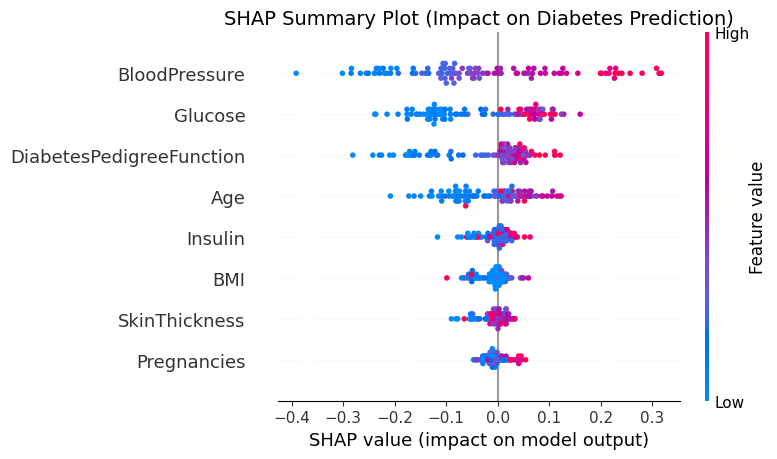


 Bar Plot:


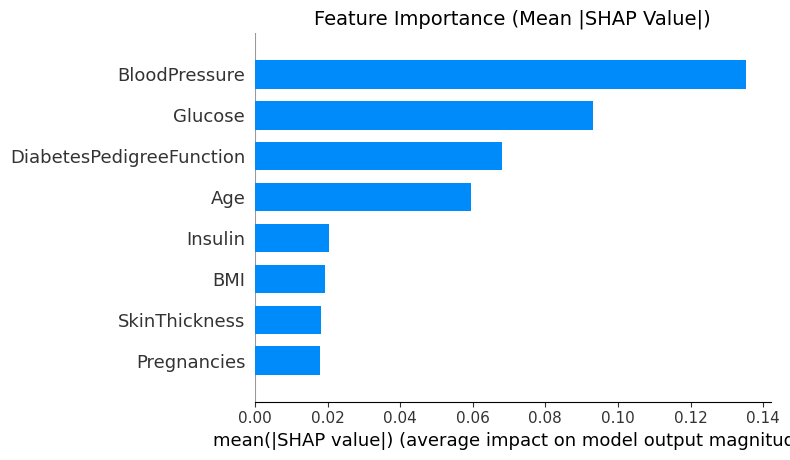


 Feature Importance Values:
  BloodPressure       : 0.1353
  Glucose             : 0.0931
  DiabetesPedigreeFunction: 0.0681
  Age                 : 0.0596
  Insulin             : 0.0205
  BMI                 : 0.0193
  SkinThickness       : 0.0181
  Pregnancies         : 0.0179
SHAP WATERFALL ANALYSIS
SAMPLE 1 PREDICTION EXPLANATION
Predicted: DIABETIC
Probability: 0.7800
Baseline probability: 0.5037


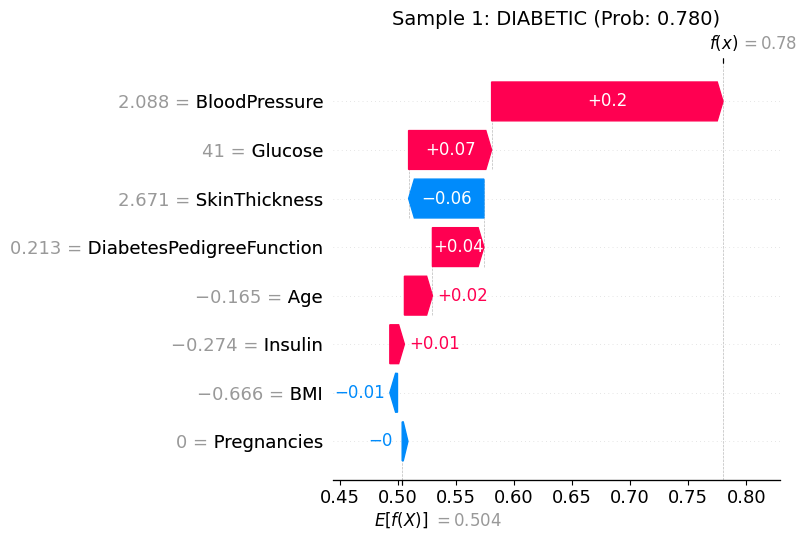


Feature Contributions:
------------------------------------------------------------
  BloodPressure        | Value:    2.1 | Impact: 0.1993 ↑ INCREASES risk
  Glucose              | Value:   41.0 | Impact: 0.0715 ↑ INCREASES risk
  SkinThickness        | Value:    2.7 | Impact: -0.0649 ↓ DECREASES risk
  DiabetesPedigreeFunction | Value:    0.2 | Impact: 0.0444 ↑ INCREASES risk
  Age                  | Value:   -0.2 | Impact: 0.0241 ↑ INCREASES risk
  Insulin              | Value:   -0.3 | Impact: 0.0126 ↑ INCREASES risk
  BMI                  | Value:   -0.7 | Impact: -0.0066 ↓ DECREASES risk
  Pregnancies          | Value:    0.0 | Impact: -0.0040 ↓ DECREASES risk
SAMPLE 2 PREDICTION EXPLANATION
Predicted: DIABETIC
Probability: 0.6000
Baseline probability: 0.5037


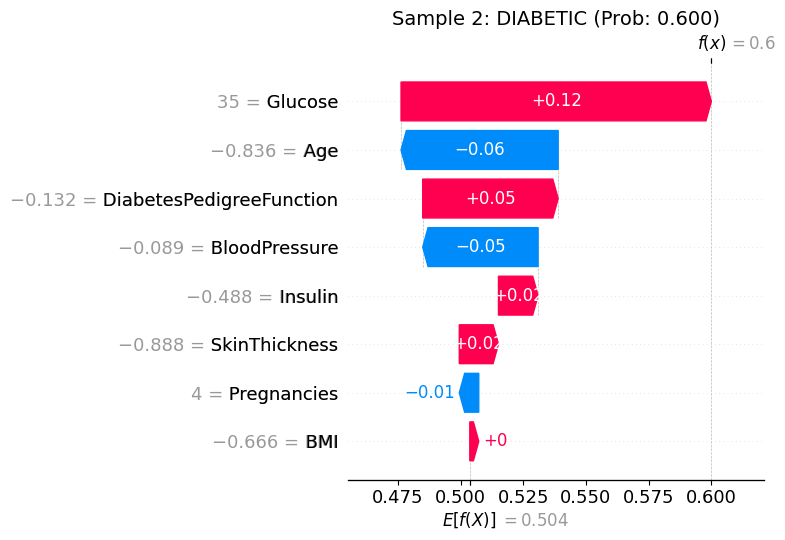


Feature Contributions:
------------------------------------------------------------
  Glucose              | Value:   35.0 | Impact: 0.1238 ↑ INCREASES risk
  Age                  | Value:   -0.8 | Impact: -0.0627 ↓ DECREASES risk
  DiabetesPedigreeFunction | Value:   -0.1 | Impact: 0.0540 ↑ INCREASES risk
  BloodPressure        | Value:   -0.1 | Impact: -0.0460 ↓ DECREASES risk
  Insulin              | Value:   -0.5 | Impact: 0.0158 ↑ INCREASES risk
  SkinThickness        | Value:   -0.9 | Impact: 0.0156 ↑ INCREASES risk
  Pregnancies          | Value:    4.0 | Impact: -0.0078 ↓ DECREASES risk
  BMI                  | Value:   -0.7 | Impact: 0.0036 ↑ INCREASES risk
SAMPLE 3 PREDICTION EXPLANATION
Predicted: NON-DIABETIC
Probability: 0.1000
Baseline probability: 0.5037


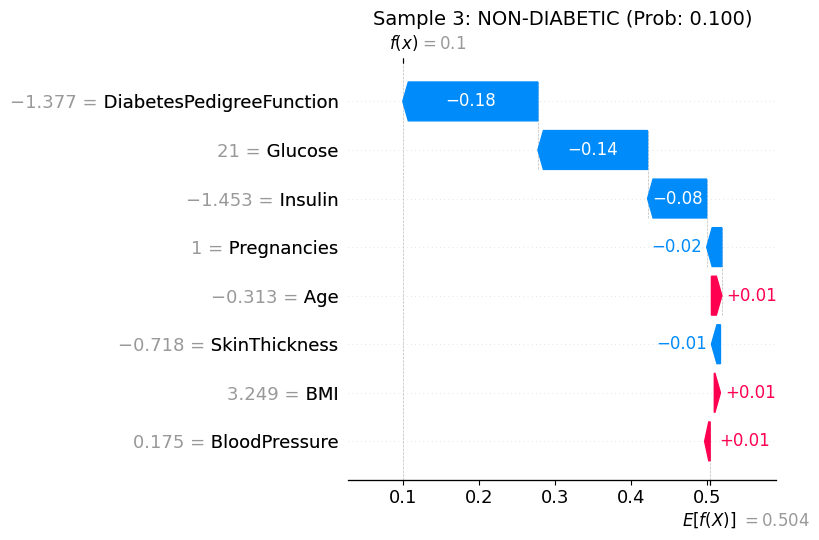


Feature Contributions:
------------------------------------------------------------
  DiabetesPedigreeFunction | Value:   -1.4 | Impact: -0.1774 ↓ DECREASES risk
  Glucose              | Value:   21.0 | Impact: -0.1440 ↓ DECREASES risk
  Insulin              | Value:   -1.5 | Impact: -0.0776 ↓ DECREASES risk
  Pregnancies          | Value:    1.0 | Impact: -0.0200 ↓ DECREASES risk
  Age                  | Value:   -0.3 | Impact: 0.0137 ↑ INCREASES risk
  SkinThickness        | Value:   -0.7 | Impact: -0.0119 ↓ DECREASES risk
  BMI                  | Value:    3.2 | Impact: 0.0081 ↑ INCREASES risk
  BloodPressure        | Value:    0.2 | Impact: 0.0055 ↑ INCREASES risk


In [44]:
print("SHAP FEATURE IMPORTANCE ANALYSIS")
print("-"*60)

import shap
import matplotlib.pyplot as plt
import numpy as np

# Use the best model
best_model = results['Random Forest']['Model']
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Create explainer and calculate SHAP values
print("\nCreating SHAP explainer")
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test[:100])  # Use subset for speed

# For binary classification, shap_values is a LIST of two arrays:
# shap_values[0] = SHAP values for class 0 (non-diabetic)
# shap_values[1] = SHAP values for class 1 (diabetic)
print(f"\nSHAP values type: {type(shap_values)}")
print(f"Length: {len(shap_values)}")
print(f"Shape of class 1 SHAP values: {shap_values[1].shape}")

# Summary plot (using class 1 - diabetic)
print("\n Summary Plot:")
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values[:, :, 1], X_test[:100], feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Impact on Diabetes Prediction)", fontsize=14)
plt.tight_layout()
plt.show()

# Bar plot (using class 1 - diabetic)
print("\n Bar Plot:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test[:100], feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Feature Importance (Mean |SHAP Value|)", fontsize=14)
plt.tight_layout()
plt.show()

# Print numerical feature importance
print("\n Feature Importance Values:")
mean_abs_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)
feature_importance = list(zip(feature_names, mean_abs_shap))
feature_importance.sort(key=lambda x: x[1], reverse=True)

for feature, importance in feature_importance:
    print(f"  {feature:20}: {importance:.4f}")
print("SHAP WATERFALL ANALYSIS")
print("="*80)

# Calculate SHAP values for waterfall plot (first 5 samples)
shap_values_waterfall = explainer.shap_values(X_test[:5])

# Show waterfall for a few samples
for i in range(min(3, len(X_test))):  # First 3 samples
    print(f"SAMPLE {i+1} PREDICTION EXPLANATION")
    print(f"{'='*60}")

    # Get prediction
    pred_prob = best_model.predict_proba(X_test[i:i+1])[0][1]
    pred_class = best_model.predict(X_test[i:i+1])[0]

    print(f"Predicted: {'DIABETIC' if pred_class == 1 else 'NON-DIABETIC'}")
    print(f"Probability: {pred_prob:.4f}")
    print(f"Baseline probability: {explainer.expected_value[1]:.4f}")

    # Create waterfall plot
    plt.figure(figsize=(12, 6))

    # For binary classification, shap_values_waterfall[i, :, 1] gives values for class 1
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_waterfall[i, :, 1],
            base_values=explainer.expected_value[1],
            data=X_test[i],
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f"Sample {i+1}: {'DIABETIC' if pred_class == 1 else 'NON-DIABETIC'} " +
              f"(Prob: {pred_prob:.3f})", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print detailed contribution
    print("\nFeature Contributions:")
    print("-" * 60)

    # Get contributions for this sample
    contributions = []
    for j, feature in enumerate(feature_names):
        impact = shap_values_waterfall[i, :, 1][j]
        value = X_test[i][j]
        contributions.append((feature, impact, value))

    # Sort by absolute impact
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    for feature, impact, value in contributions:
        direction = "↑ INCREASES risk" if impact > 0 else "↓ DECREASES risk"
        print(f"  {feature:20} | Value: {value:6.1f} | Impact: {impact:6.4f} {direction}")